# Import Dataset

In [1]:
#import the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import time
%matplotlib inline

In [2]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', None)
data = pd.read_csv('./OnlineRetail.csv')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom


# **TO-DO:** Data Preprocessing

In [3]:
# **TO-DO** Print the number of duplicate items
print("Duplicate Items in Dataset", data.duplicated().sum())

Duplicate Items in Dataset 5268


## **TO-DO:** Remove Duplicate items from dataset

In [4]:
# **TO-DO** Remove duplicate items from the dataset
data = data.drop_duplicates()

## **TO-DO:** Check for missing values

In [5]:
# **TO-DO** Display count of missing values
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

## **TO-DO:** Create new Invoice List

In [10]:
# **TO-DO** Creates a list of unique invoice No. with Null Customer ID
invoice_list = data[data['CustomerID'].isnull()]['InvoiceNo'].unique()

In [11]:
print("InvoiceLise: ", invoice_list[:10])
print("Invoice Size:", len(invoice_list))

InvoiceLise:  ['536414' '536544' '536545' '536546' '536547' '536549' '536550' '536552'
 '536553' '536554']
Invoice Size: 3710


## **TO-DO:** Removing Inconsistent Records

In [22]:

first = data[(data['Quantity'] < 0) & (data['UnitPrice'] == 0)]
sec = data[(data['Quantity'] < 0) & (data['UnitPrice'] > 0)]
sem = data[(data['Quantity'] > 0) & (data['UnitPrice'] == 0)]

total_qty = len(first) 
print("The number of records with Quantity Negative and Prices 0 or Vice versa :", total_qty)


# **TO-DO** Checking if Negative quantities are cancelled items
cancelled_invoices = data['InvoiceNo'][data['InvoiceNo'].str.startswith('C', na=False)].unique()
print("Cancelled Items have Invoice Starting with :", cancelled_invoices[:5], "...")  

# **TO-DO** Checking for Records with Negative Unit Price
neg_unitprice_count = len(data[data['UnitPrice'] < 0])
print("The number of transactions with Negative Unit Price :", neg_unitprice_count)

# **TO-DO** Checking for Records with Unit Price 0
zero_unitprice_count = len(data[data['UnitPrice'] == 0])
print("The number of transactions with Unit Price 0 :", zero_unitprice_count)


The number of records with Quantity Negative and Prices 0 or Vice versa : 1336
Cancelled Items have Invoice Starting with : ['C536379' 'C536383' 'C536391' 'C536506' 'C536543'] ...
The number of transactions with Negative Unit Price : 2
The number of transactions with Unit Price 0 : 2510


In [26]:
# **TO-DO** Removing records with Null Customer ID
data = data.dropna(subset=['CustomerID'])

In [27]:
# Copy the dataset and convert CustomerID to int
rfm_train = data.copy()
rfm_train.CustomerID = (rfm_train.CustomerID).astype(int)

In [28]:
# **TO-DO** Count the number of missing values
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Cancelled Items


In [33]:
## remove transactions with Cancelled Items.
placed = rfm_train[~rfm_train.InvoiceNo.str.contains('C',na=False)]


In [34]:
placed['TotalCost'] = rfm_train.Quantity * rfm_train.UnitPrice

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/140923902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed['TotalCost'] = rfm_train.Quantity * rfm_train.UnitPrice


In [35]:
placed.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalCost
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34


# **TO-DO:** Exploratory Data Analysis

In [36]:
# **TO-DO** Find The Time Period of Transactions
placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])

start_date = placed['InvoiceDate'].min()
end_date = placed['InvoiceDate'].max()

print("Oldest Date:", start_date)
print("Latest Date  :", end_date)

Oldest Date: 2010-12-01 08:26:00
Latest Date  : 2011-12-09 12:50:00


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/2411630092.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])


## **TO-DO:** Order Density in Different Countries

In [41]:
# **TO-DO** Display the proportion of order based on country as below

country_counts = placed['Country'].value_counts()
country_percent = round(country_counts / country_counts.sum() * 100, 2)

print("Proportion of orders by Country (%):")
print(country_percent)

Proportion of orders by Country (%):
Country
United Kingdom         88.92
Germany                 2.30
France                  2.12
EIRE                    1.84
Spain                   0.63
Netherlands             0.60
Belgium                 0.52
Switzerland             0.47
Portugal                0.37
Australia               0.30
Norway                  0.27
Italy                   0.19
Channel Islands         0.19
Finland                 0.17
Cyprus                  0.15
Sweden                  0.11
Austria                 0.10
Denmark                 0.10
Poland                  0.08
Japan                   0.08
Israel                  0.06
Unspecified             0.06
Singapore               0.06
Iceland                 0.05
USA                     0.05
Canada                  0.04
Greece                  0.04
Malta                   0.03
United Arab Emirates    0.02
European Community      0.02
RSA                     0.01
Lebanon                 0.01
Lithuania               0.0

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/1525341215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])
/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/1525341215.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed['Year'] = placed['InvoiceDate'].dt.year


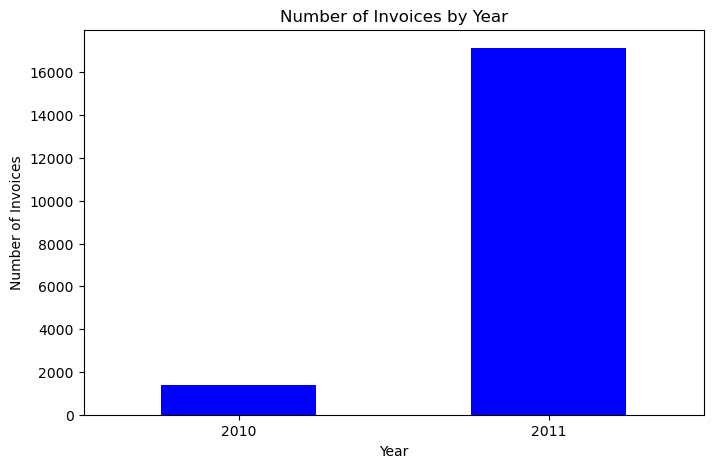

In [47]:
# **TO-DO** Produce the following Bar Graph Below comparing the number invoices by year
placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])
placed['Year'] = placed['InvoiceDate'].dt.year

invoices_per_year = placed.groupby('Year')['InvoiceNo'].nunique()

plt.figure(figsize=(8,5))
invoices_per_year.plot(kind='bar', color='blue')
plt.title("Number of Invoices by Year")
plt.xlabel("Year")
plt.ylabel("Number of Invoices")
plt.xticks(rotation=0)
plt.show()


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/4245116596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])
/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/4245116596.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed['Year'] = placed['InvoiceDate'].dt.year
/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/4245116596.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of

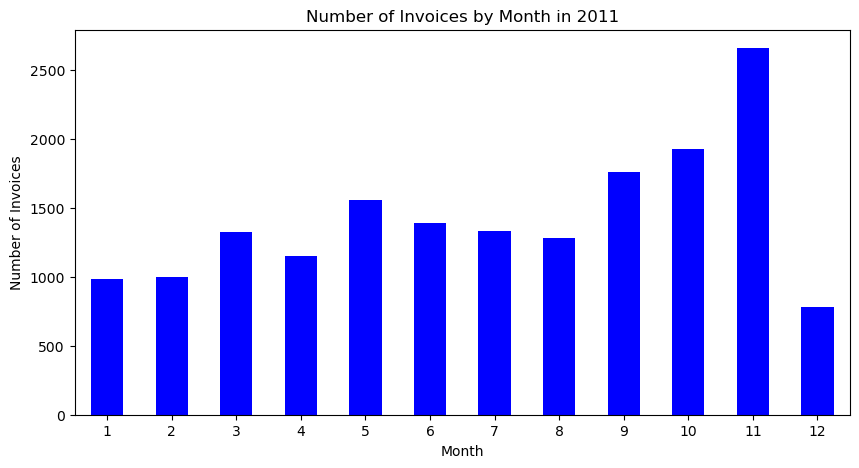

In [50]:
# **TO-DO** Produce the following Bar Graph Below comparing the number invoices by month in 2011
placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])
placed['Year'] = placed['InvoiceDate'].dt.year
placed['Month'] = placed['InvoiceDate'].dt.month

placed_2011 = placed[placed['Year'] == 2011]

invoices_per_month = placed_2011.groupby('Month')['InvoiceNo'].nunique()

plt.figure(figsize=(10,5))
invoices_per_month.plot(kind='bar', color='blue')
plt.title("Number of Invoices by Month in 2011")
plt.xlabel("Month")
plt.ylabel("Number of Invoices")
plt.xticks(rotation=0)
plt.show()

## **Monthly Gross**

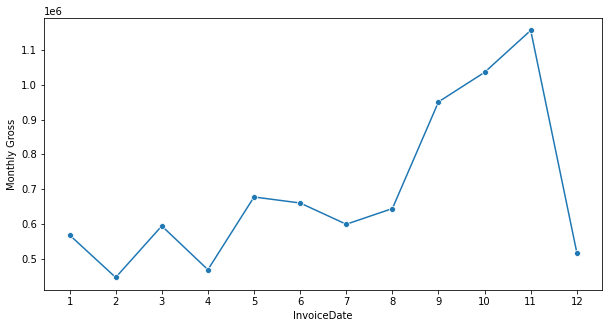

In [ ]:
# **TO-DO** Produce the following Bar Graph Below comparing the monthly gross rate in 2011


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/1524880571.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])


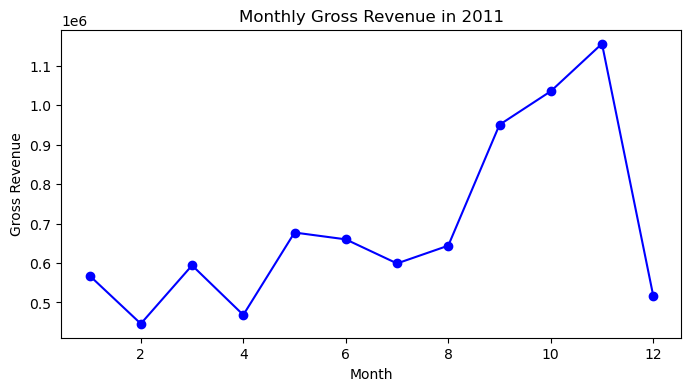

In [58]:
# you have said that bar graph but in the picture it is not bar graph
placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])
placed_2011 = placed[placed['InvoiceDate'].dt.year == 2011].copy()

placed_2011['TotalCost'] = placed_2011['Quantity'] * placed_2011['UnitPrice']

placed_2011['Month'] = placed_2011['InvoiceDate'].dt.month

monthly_gross = placed_2011.groupby('Month')['TotalCost'].sum()

plt.figure(figsize=(8,4))
monthly_gross.plot(kind='line', color='blue', marker='o')
plt.title("Monthly Gross Revenue in 2011")
plt.xlabel("Month")
plt.ylabel("Gross Revenue")
plt.xticks(rotation=0)
plt.show()

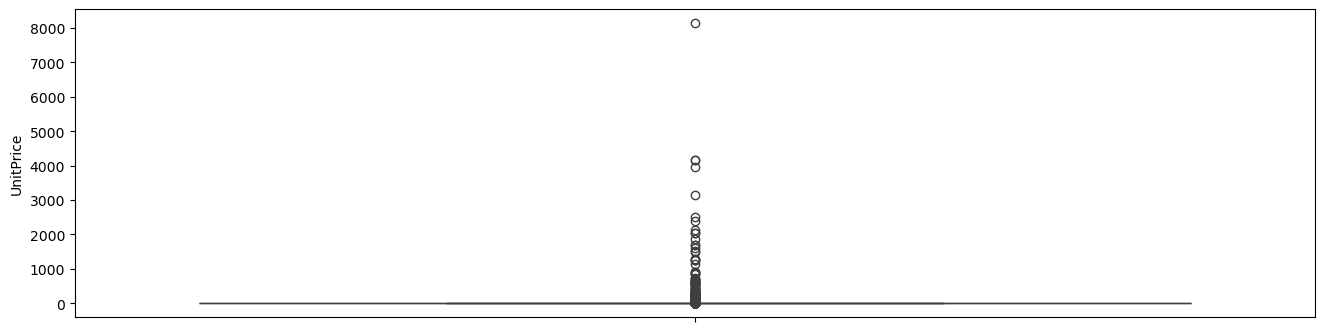

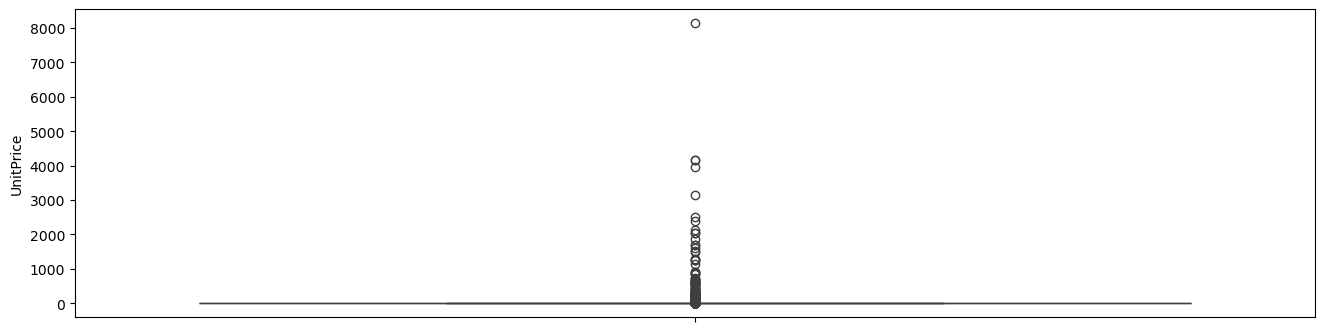

In [60]:
plt.figure(figsize=(16,4))
sns.boxplot(y='UnitPrice',data = placed,orient=("Horizontal", "y"))
plt.show()

Unit Price is more concentrated in lower values of prices.

## **Top Selling Products**

In [61]:
placed.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalCost,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12


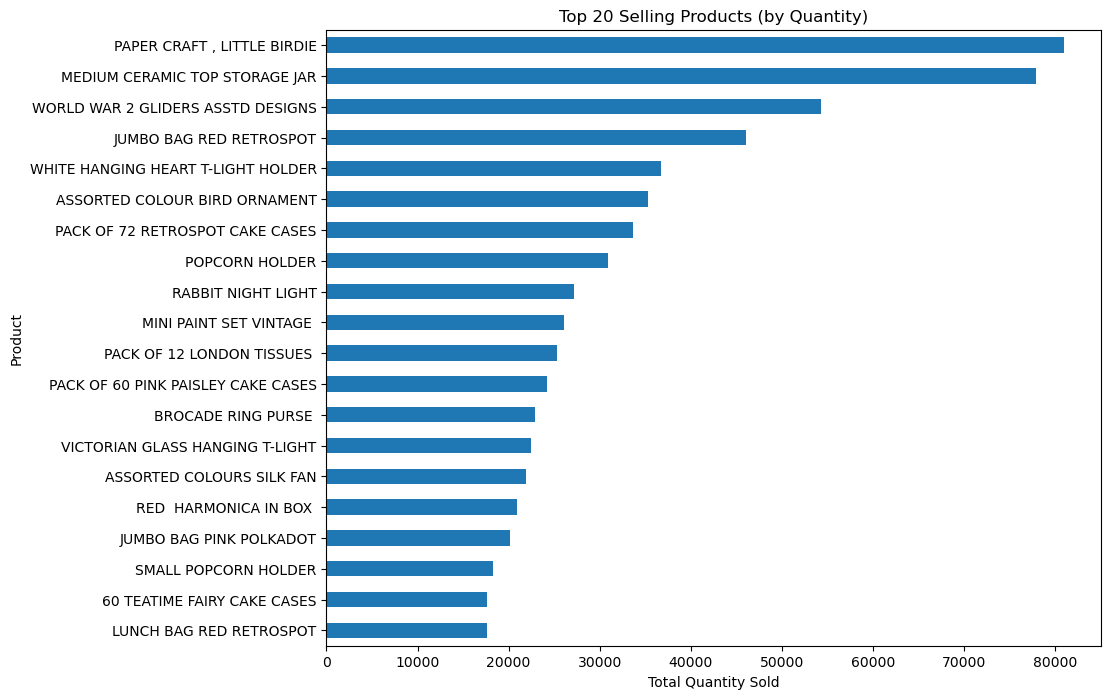

In [65]:
# **TO-DO** Produce the following Graph displaying the top 20 selling products
top_products = placed.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,8))
top_products.plot(kind='barh')  
plt.title("Top 20 Selling Products (by Quantity)")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis() 
plt.show()

# **TO-DO:** Receny, Frequency, Montary (RFM) ANALYSIS               

## **TO-DO:** Recency

In [66]:
# **TO-DO** Print Lastest date in the Order History
placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])

latest_date = placed['InvoiceDate'].max()
print(latest_date)


2011-12-09 12:50:00


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/601409394.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed['InvoiceDate'] = pd.to_datetime(placed['InvoiceDate'])


In [74]:
current_date = pd.Timestamp(dt.date(2011, 12, 10))

In [75]:
rfm_train['InvoiceDate'] = pd.to_datetime(rfm_train['InvoiceDate'], errors='coerce')
rfm_train['Purchase_Date'] = rfm_train.InvoiceDate.dt.date
print(rfm_train['Purchase_Date'])

0         2010-12-01
1         2010-12-01
2         2010-12-01
3         2010-12-01
4         2010-12-01
             ...    
541904    2011-12-09
541905    2011-12-09
541906    2011-12-09
541907    2011-12-09
541908    2011-12-09
Name: Purchase_Date, Length: 401604, dtype: object


**TO-DO** Create Seperate Column for Recency

In [72]:
recency = rfm_train.groupby('CustomerID')['Purchase_Date'].max().reset_index()

In [76]:
# **TO-DO** Calculate Recency based on purchase date and current date
recency['Recency'] = recency['Purchase_Date'].apply(lambda x: (current_date - x).days)

# Display Recency
recency.head()

,CustomerID,Purchase_Date,Recency
0,12346,2011-01-18,326
1,12347,2011-12-07,3
2,12348,2011-09-25,76
3,12349,2011-11-21,19
4,12350,2011-02-02,311


In [78]:
# **TO-DO** Drop Date Columns which are not useful anymore.
recency = recency.drop(columns=['Purchase_Date'])

recency.head()

,CustomerID,Recency
0,12346,326
1,12347,3
2,12348,76
3,12349,19
4,12350,311


**TO-DO** Create Seperate Column for Frequency

In [79]:
# **TO-DO** Calculate Frequency based on Customer ID
frequency = rfm_train.groupby('CustomerID').size().reset_index(name='Frequency')

frequency.head()

,CustomerID,Frequency
0,12346,2
1,12347,182
2,12348,31
3,12349,73
4,12350,17


**TO-DO** Create seperate Column for Monetary

In [82]:
# **TO-DO** Calculate Total Cost (Quantity * Price)
rfm_train['TotalCost'] = rfm_train['Quantity'] * rfm_train['UnitPrice']

rfm_train.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Purchase_Date,TotalCost
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12-01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34


In [83]:
# **TO-DO** Calculate Monetary based on total cost per Customer
monetary = rfm_train.groupby('CustomerID')['TotalCost'].sum().reset_index(name='Monetary')

monetary.head()

,CustomerID,Monetary
0,12346,0.00
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


## **TO-DO:** Combine Recency, Frequency and Monetary

In [84]:
# **TO-DO** Combine Recency, Frequency and Monetary into a single table
rfm_table = recency.merge(frequency, on='CustomerID')

rfm_table = rfm_table.merge(monetary, on='CustomerID')

rfm_table.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,2,0.00
1,12347,3,182,4310.00
2,12348,76,31,1797.24
3,12349,19,73,1757.55
4,12350,311,17,334.40


## **TO-DO:** QQ Plot

In [85]:
from scipy import stats
from scipy.stats import skew, norm, probplot, boxcox

def QQ_plot(data, measure):
    fig = plt.figure(figsize=(20,7))

    #Get the fitted parameters used by the function
    (mu, sigma) = norm.fit(data)

    #Kernel Density plot
    fig1 = fig.add_subplot(121)
    sns.distplot(data, fit=norm)
    fig1.set_title(measure + ' Distribution ( mu = {:.2f} and sigma = {:.2f} )'.format(mu, sigma), loc='center')
    fig1.set_xlabel(measure)
    fig1.set_ylabel('Frequency')

    #QQ plot
    fig2 = fig.add_subplot(122)
    res = probplot(data, plot=fig2)
    fig2.set_title(measure + ' Probability Plot (skewness: {:.6f} and kurtosis: {:.6f} )'.format(data.skew(), data.kurt()), loc='center')

    plt.tight_layout()
    plt.show()

A Quantile-Quantile (QQ) plot is a graphical tool to assess if a dataset follows a specified distribution, typically the normal distribution. It does this by plotting the quantiles of the dataset against the quantiles of the theoretical distribution. If the points roughly follow a straight line, the data is approximately normally distributed.
Key Components of a QQ Plot

How to Interpret a QQ Plot

    Straight Line: If the points form a roughly straight line, the data follows the theoretical distribution.
    S-shaped Curve: If the points form an S-shape, the data may have heavier tails than the theoretical distribution.
    Convex/Concave Curve: Indicates a skewness in the data.

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/1895157362.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, fit=norm)


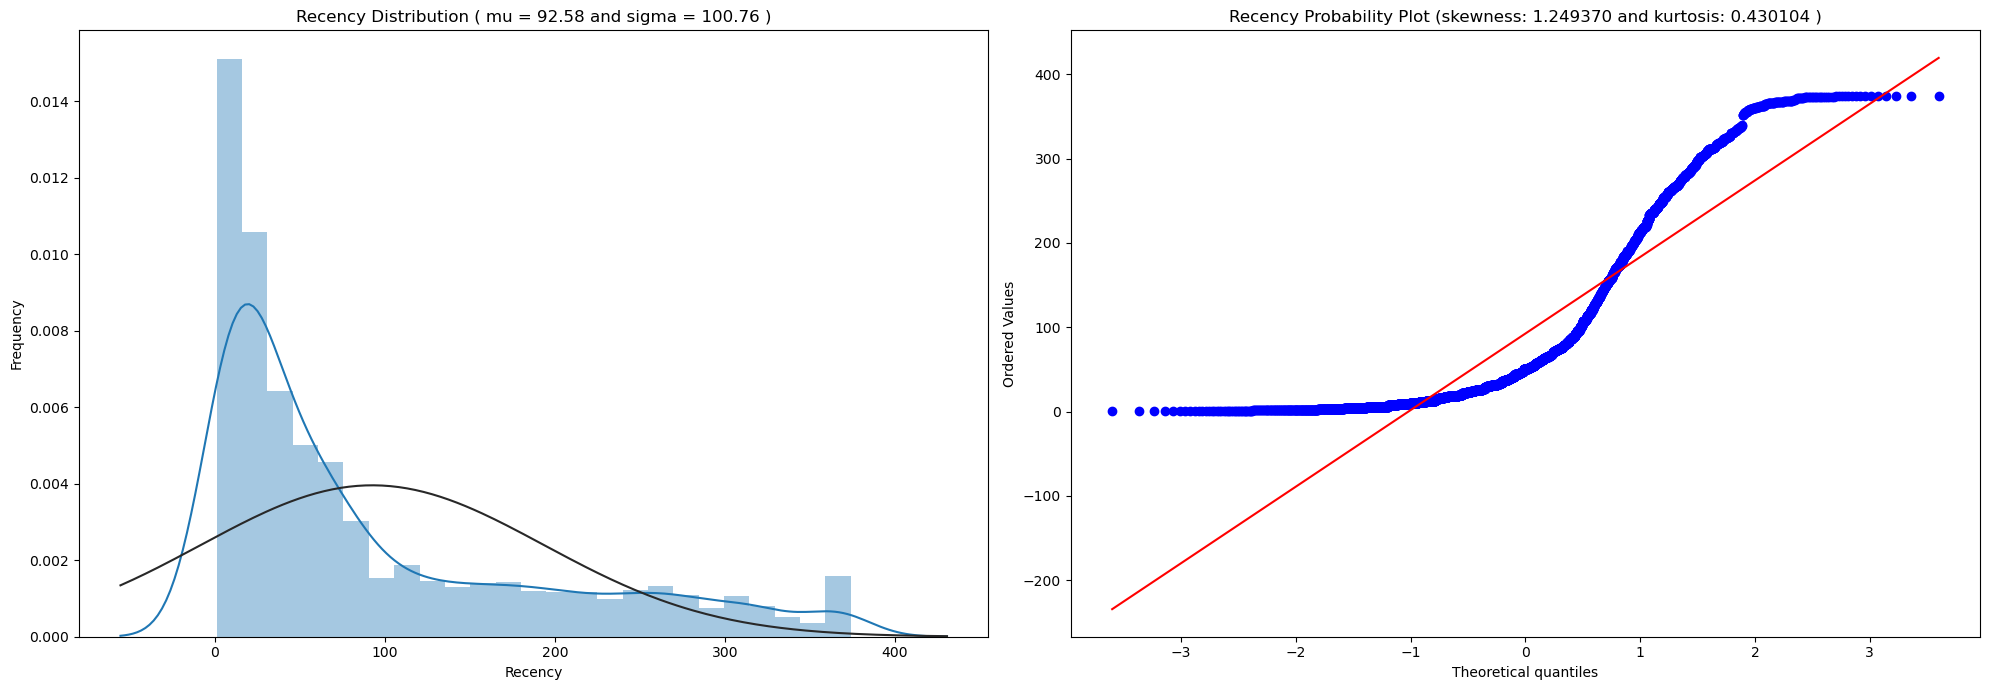

In [86]:
# **TO-DO** Generate the below Recency graphs using the QQ_plot function
QQ_plot(rfm_table['Recency'], 'Recency')

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/1895157362.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, fit=norm)


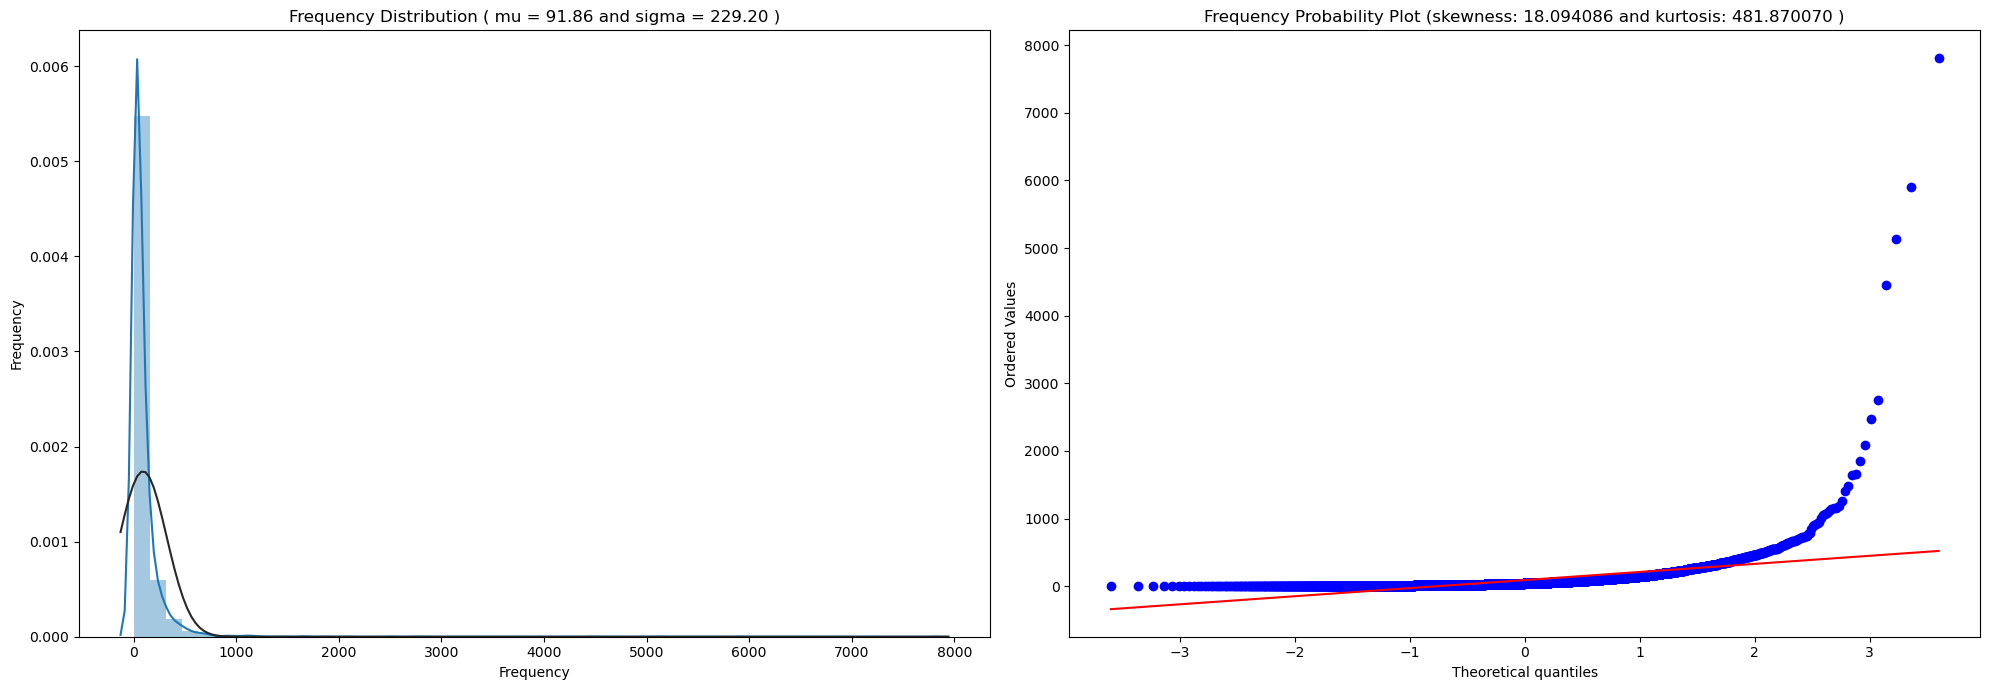

In [87]:
# **TO-DO** Generate the below Frequency graphs using the QQ_plot function
QQ_plot(rfm_table['Frequency'], 'Frequency')

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/1895157362.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data, fit=norm)


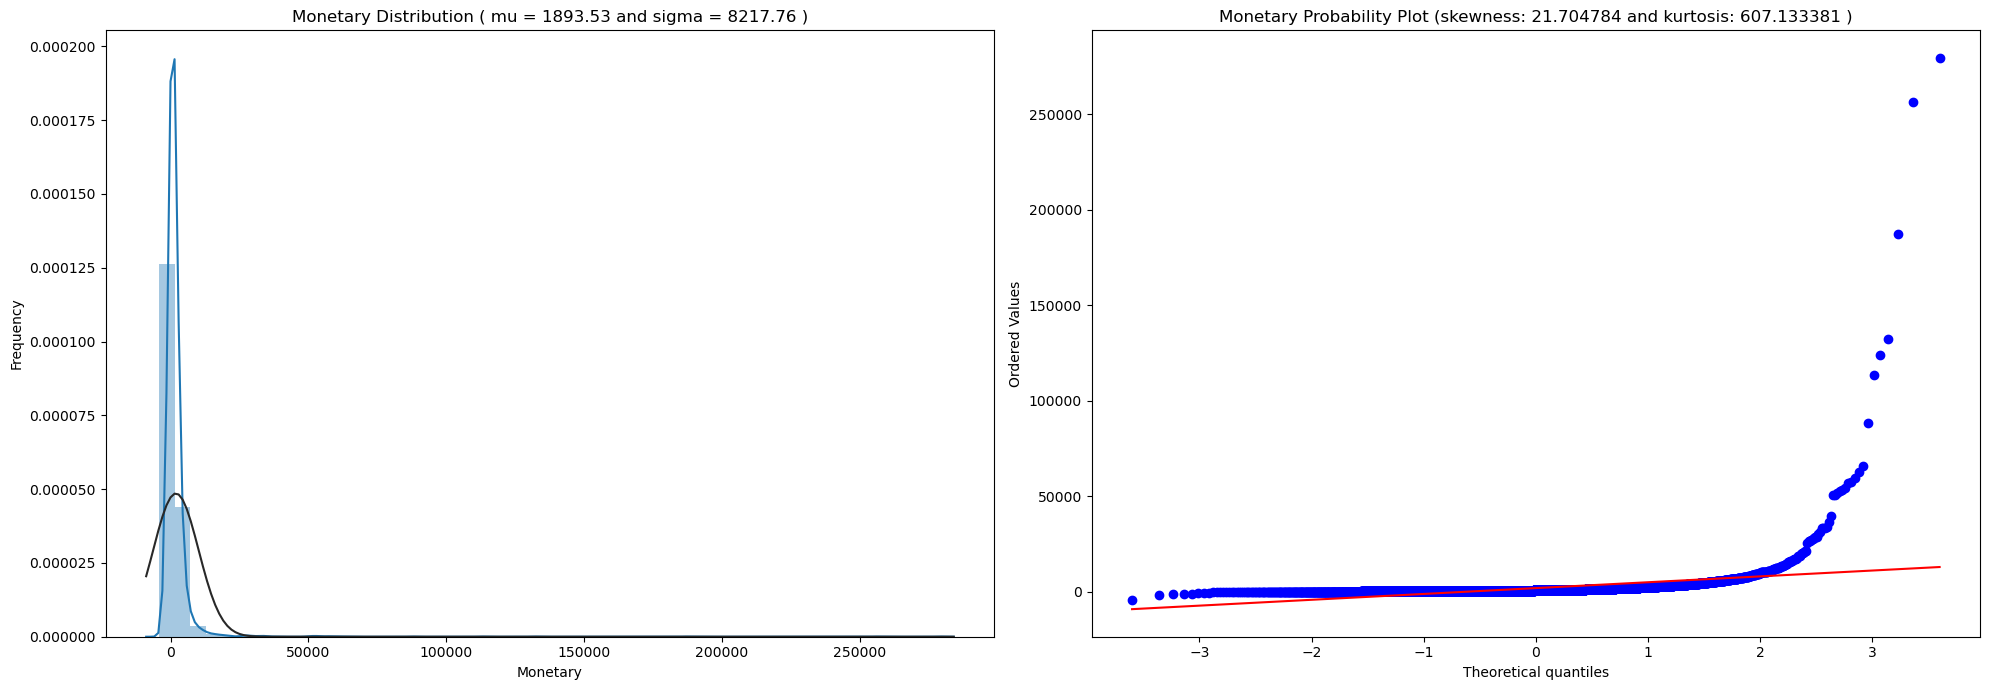

In [88]:
# **TO-DO** Generate the below Monetary graphs using the QQ_plot function
QQ_plot(rfm_table['Monetary'], 'Monetary')

# **Customer Segmentation Using Quantiles**

In [89]:
# **TO-DO** Calcualte the quantils for recency, frenuency, and monetary
quantil = rfm_table[['Recency', 'Frequency', 'Monetary']].quantile([0.25, 0.5, 0.75])

print(quantil)

      Recency  Frequency  Monetary
0.25    17.00      17.00    291.80
0.50    51.00      41.00    644.07
0.75   144.00      99.25   1608.34


Quantiles in General:

    0.25 Quantile (25th Percentile): This is the value below which 25% of the data falls. It’s also known as the
    first quartile.
    0.50 Quantile (50th Percentile): This is the median, the middle value of the data. Half of the data lies below
    this value.
    0.75 Quantile (75th Percentile): This is the value below which 75% of the data falls. It’s also known as the
    third quartile.

In [90]:
# Convert quantil into dict to access each value
quantil = quantil.to_dict()
print(quantil)

{'Recency': {0.25: 17.0, 0.5: 51.0, 0.75: 144.0}, 'Frequency': {0.25: 17.0, 0.5: 41.0, 0.75: 99.25}, 'Monetary': {0.25: 291.795, 0.5: 644.0699999999999, 0.75: 1608.335}}


    RecencyPoints Function: Assigns points to customers based on how recently they made their last purchase, giving
    higher scores (4) to more recent purchases.
    Freq_MonetaryPoints Function: Assigns points to customers based on their purchase frequency and monetary value,
    giving higher scores to more frequent and higher spending customers.
    Application: These functions are applied to the DataFrame to segment customers into quartiles for each RFM
    metric, facilitating further analysis and customer segmentation.

By applying these functions, businesses can better understand customer behavior and tailor marketing strategies accordingly, targeting different customer segments based on their RFM scores.

In [91]:
# **TO-DO** Define the recency points function
# 0-25% = 4 / 25%-50% = 3 / 50%-75% = 2 / 75%-100% = 1
def RecencyPoints(x, rfm, quantil):
    if x <= quantil['Recency'][0.25]:
        return 4
    elif x <= quantil['Recency'][0.50]:
        return 3
    elif x <= quantil['Recency'][0.75]:
        return 2
    else:
        return 1

# **TO-DO** Define the recency points function
# 0-25% = 4 / 25%-50% = 3 / 50%-75% = 2 / 75%-100% = 1
def Freq_MonetaryPoints(x, rfm, quantil, column_name):
    if x <= quantil[column_name][0.25]:
        return 1
    elif x <= quantil[column_name][0.50]:
        return 2
    elif x <= quantil[column_name][0.75]:
        return 3
    else:
        return 4

In [92]:
# Copy RFM Table
rfm_segment = rfm_table.copy()

# **TO-DO** Apply RecencyPoint and MonetaryPoints function to Calculate Recency_Quartile, Frequency_Quartile, Monetary_Quartile

rfm_segment['Recency_Quartile'] = rfm_segment['Recency'].apply(lambda x: RecencyPoints(x, rfm_segment, quantil))

rfm_segment['Frequency_Quartile'] = rfm_segment['Frequency'].apply(lambda x: Freq_MonetaryPoints(x, rfm_segment, quantil, 'Frequency'))

rfm_segment['Monetary_Quartile'] = rfm_segment['Monetary'].apply(lambda x: Freq_MonetaryPoints(x, rfm_segment, quantil, 'Monetary'))


rfm_segment.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Quartile,Frequency_Quartile,Monetary_Quartile
0,12346,326,2,0.00,1,1,1
1,12347,3,182,4310.00,4,4,4
2,12348,76,31,1797.24,2,2,4
3,12349,19,73,1757.55,3,3,4
4,12350,311,17,334.40,1,1,2


RFM Classification

In [93]:
rfm_segment['RFMPoints'] = rfm_segment.Recency_Quartile.map(str)+rfm_segment.Frequency_Quartile.map(str)+rfm_segment.Monetary_Quartile.map(str)
print(rfm_segment['RFMPoints'])

0       111
1       444
2       224
3       334
4       112
       ... 
4367    111
4368    111
4369    411
4370    444
4371    334
Name: RFMPoints, Length: 4372, dtype: object


In [94]:
customer_dict = {'Best Customers':'444','Loyal Customers':'344','Big Spender':'334','Almost Lost':'244','Lost Customers':'144','Recent Customers':'443','Lost Cheap Customers':'122'}
dict_segment = dict(zip( customer_dict.values(),customer_dict.keys()))

In [95]:
# Segment Customers based on RFM Points
rfm_segment['Segment'] = rfm_segment.RFMPoints.map(lambda x:dict_segment.get(x))
rfm_segment.Segment.fillna('others',inplace = True)

rfm_segment.sample(10)

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/3954248131.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rfm_segment.Segment.fillna('others',inplace = True)


,CustomerID,Recency,Frequency,Monetary,Recency_Quartile,Frequency_Quartile,Monetary_Quartile,RFMPoints,Segment
1175,13927,75,21,348.99,2,2,2,222,others
706,13272,32,15,276.56,3,1,1,311,others
865,13495,8,52,1990.12,4,3,4,434,others
1897,14913,36,87,1227.43,3,3,3,333,others
3315,16828,94,8,128.50,2,1,1,211,others
1367,14189,3,277,4604.31,4,4,4,444,Best Customers
2018,15088,22,60,1140.27,3,3,3,333,others
664,13218,128,5,62.64,2,1,1,211,others
1819,14804,9,12,353.27,4,1,2,412,others
3667,17334,302,12,306.60,1,1,2,112,others


In [96]:
# **TO-DO** Display Best Customers whose recency, frequency as well as monetary attributes are the highest.
best_customers = rfm_segment[
    (rfm_segment['Recency_Quartile'] == 4) &
    (rfm_segment['Frequency_Quartile'] == 4) &
    (rfm_segment['Monetary_Quartile'] == 4)
]

best_customers.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Quartile,Frequency_Quartile,Monetary_Quartile,RFMPoints,Segment
1,12347,3,182,4310.00,4,4,4,444,Best Customers
12,12359,8,251,6182.98,4,4,4,444,Best Customers
15,12362,4,274,5154.58,4,4,4,444,Best Customers
34,12388,16,100,2780.66,4,4,4,444,Best Customers
39,12395,16,159,2998.28,4,4,4,444,Best Customers


In [100]:
# **TO-DO** Display Big Spenders
big_spenders = rfm_segment[rfm_segment['Segment'] == 'Big Spender']

big_spenders.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Quartile,Frequency_Quartile,Monetary_Quartile,RFMPoints,Segment
3,12349,19,73,1757.55,3,3,4,334,Big Spender
9,12356,23,59,2811.43,3,3,4,334,Big Spender
21,12371,45,63,1887.96,3,3,4,334,Big Spender
41,12398,46,85,1635.66,3,3,4,334,Big Spender
48,12407,50,77,1708.12,3,3,4,334,Big Spender


In [101]:
# **TO-DO** Display Almost Lost who's recency is very low
almost_lost = rfm_segment[rfm_segment['Recency_Quartile'] == 1]

almost_lost.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Quartile,Frequency_Quartile,Monetary_Quartile,RFMPoints,Segment
0,12346,326,2,0.00,1,1,1,111,others
4,12350,311,17,334.40,1,1,2,112,others
6,12353,205,4,89.00,1,1,1,111,others
7,12354,233,58,1079.40,1,3,3,133,others
8,12355,215,13,459.40,1,1,2,112,others


In [102]:
# **TO-DO** DisplayLost customers that don't need attention whose recency, frequency as well as monetary values are low
lost_customers = rfm_segment[rfm_segment['Segment'] == 'Lost Cheap Customers']

lost_customers.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Quartile,Frequency_Quartile,Monetary_Quartile,RFMPoints,Segment
18,12365,292,23,320.69,1,2,2,122,Lost Cheap Customers
54,12414,218,18,562.41,1,2,2,122,Lost Cheap Customers
64,12426,195,30,582.73,1,2,2,122,Lost Cheap Customers
82,12447,244,26,476.49,1,2,2,122,Lost Cheap Customers
118,12493,166,23,416.79,1,2,2,122,Lost Cheap Customers


In [103]:
# **TO-DO** Display loyal customers whose purchase frequency is high
loyal_customers = rfm_segment[rfm_segment['Segment'] == 'Loyal Customers']

loyal_customers.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Quartile,Frequency_Quartile,Monetary_Quartile,RFMPoints,Segment
10,12357,34,131,6207.67,3,4,4,344,Loyal Customers
29,12380,22,105,2720.56,3,4,4,344,Loyal Customers
40,12397,36,126,2409.90,3,4,4,344,Loyal Customers
47,12406,23,108,3280.75,3,4,4,344,Loyal Customers
49,12408,33,113,2842.57,3,4,4,344,Loyal Customers


In [104]:
# **TO-DO** Display customers that you must retain are those whose monetary and frequency was high but recency reduced quite a lot recently
loyal_customers = rfm_segment[rfm_segment['Segment'] == 'Almost Lost']

loyal_customers.head()

,CustomerID,Recency,Frequency,Monetary,Recency_Quartile,Frequency_Quartile,Monetary_Quartile,RFMPoints,Segment
13,12360,53,129,2662.06,2,4,4,244,Almost Lost
20,12370,52,166,3541.94,2,4,4,244,Almost Lost
27,12378,130,219,4008.62,2,4,4,244,Almost Lost
50,12409,79,114,11056.93,2,4,4,244,Almost Lost
124,12502,96,147,3723.87,2,4,4,244,Almost Lost


# **RFM Distribution Visualization**

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/318202995.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rfm_table.Recency,color='Red',axlabel='Recency',ax=axes[0])
/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/318202995.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe575

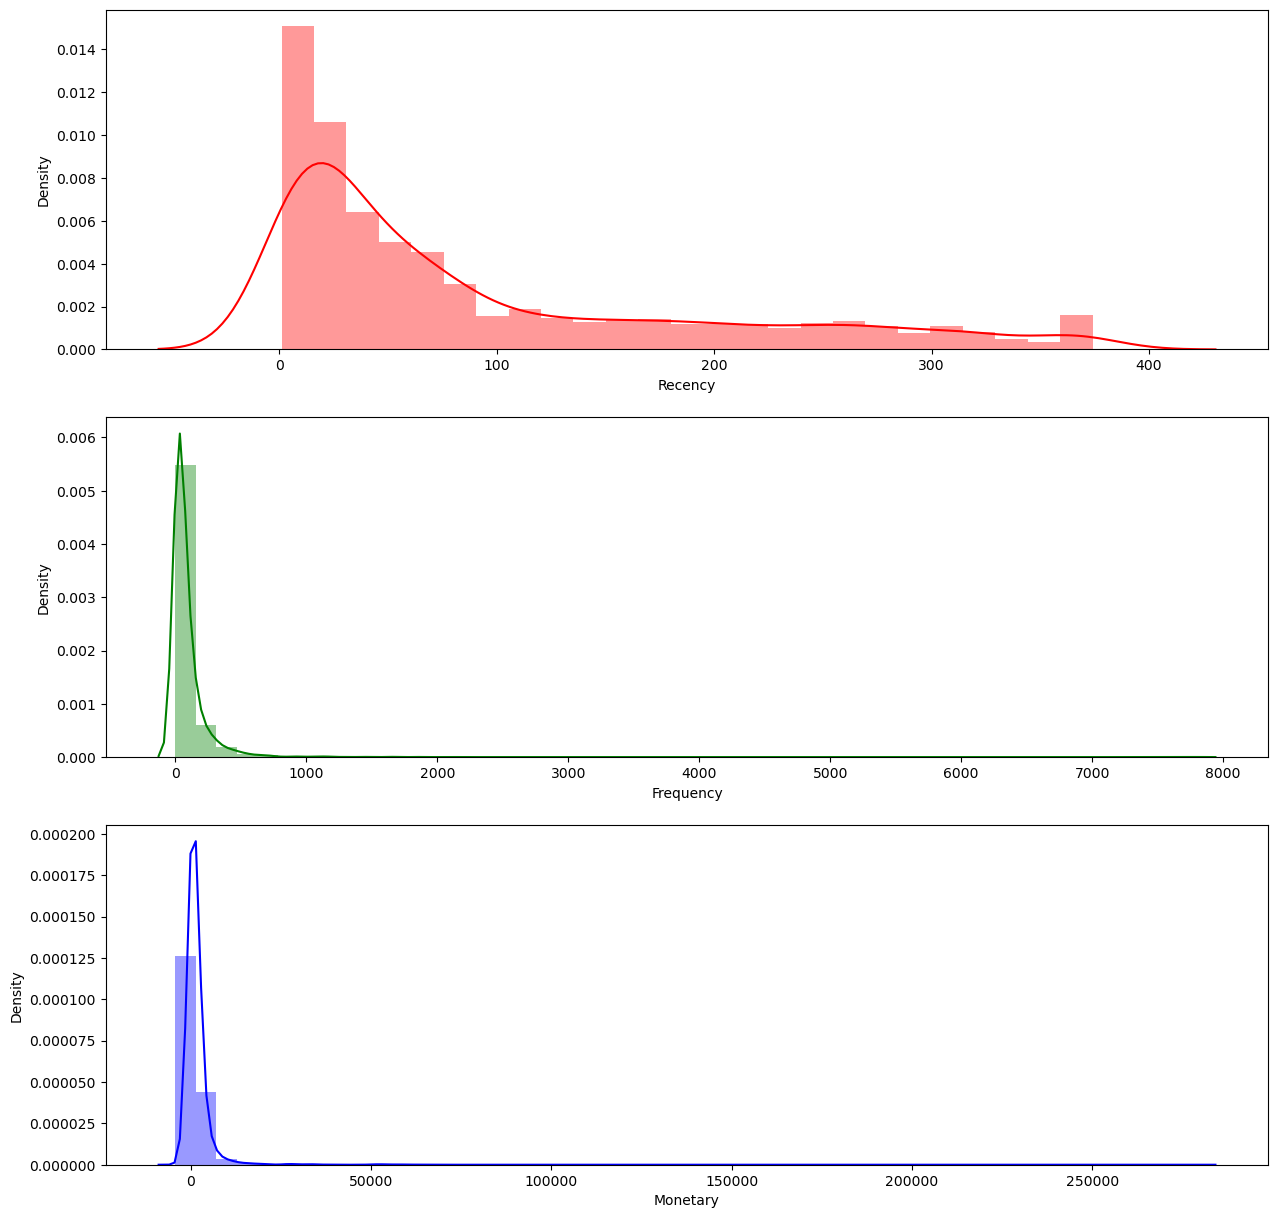

In [105]:
fig,axes = plt.subplots(3,1,figsize=(15,15))
sns.distplot(rfm_table.Recency,color='Red',axlabel='Recency',ax=axes[0])
sns.distplot(rfm_table.Frequency,color='Green',axlabel='Frequency',ax=axes[1])
sns.distplot(rfm_table.Monetary,color='Blue',axlabel='Monetary',ax=axes[2])
plt.show()

In [106]:
rfm_table.describe()

,CustomerID,Recency,Frequency,Monetary
count,4372.00,4372.00,4372.00,4372.00
mean,15299.68,92.58,91.86,1893.53
std,1722.39,100.77,229.22,8218.70
min,12346.00,1.00,1.00,-4287.63
25%,13812.75,17.00,17.00,291.80
50%,15300.50,51.00,41.00,644.07
75%,16778.25,144.00,99.25,1608.34
max,18287.00,374.00,7812.00,279489.02


In [107]:
scaled_rfm = rfm_table.copy()
scaled_rfm.Monetary = rfm_table.Monetary + abs(rfm_table.Monetary.min())+1
scaled_rfm.Recency = rfm_table.Recency + abs(rfm_table.Recency.min())+1
scaled_rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4372.00,4372.00,4372.00,4372.00
mean,15299.68,94.58,91.86,6182.16
std,1722.39,100.77,229.22,8218.70
min,12346.00,3.00,1.00,1.00
25%,13812.75,19.00,17.00,4580.43
50%,15300.50,53.00,41.00,4932.70
75%,16778.25,146.00,99.25,5896.97
max,18287.00,376.00,7812.00,283777.65


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/1296018613.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(normal_.Recency , color="Red", ax=axes[0], axlabel='Recency')
/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_71275/1296018613.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750

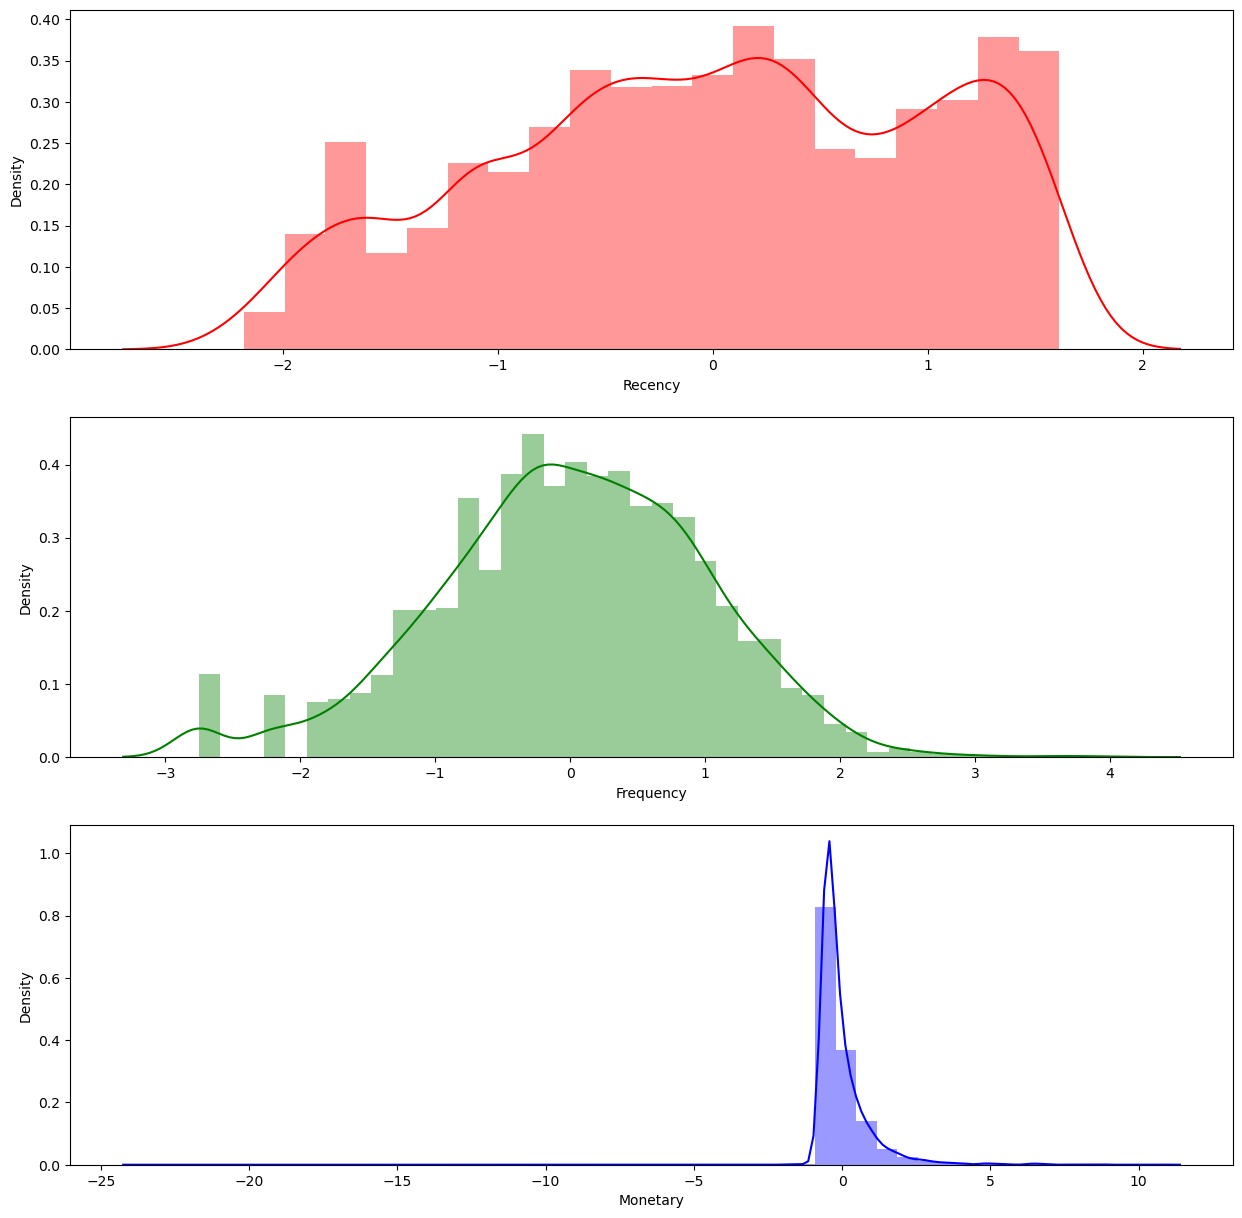

In [108]:
import numpy as np

from sklearn.preprocessing import StandardScaler

log_df = np.log(scaled_rfm)
scal = StandardScaler()
normal_ = scal.fit_transform(log_df)
normal_ = pd.DataFrame(data=normal_,index = rfm_table.index,columns=rfm_table.columns)

fig, axes = plt.subplots(3, 1, figsize=(15, 15))
sns.distplot(normal_.Recency , color="Red", ax=axes[0], axlabel='Recency')
sns.distplot(normal_.Frequency , color="Green", ax=axes[1], axlabel='Frequency')
sns.distplot(normal_.Monetary , color="Blue", ax=axes[2], axlabel='Monetary')
plt.show()